In [1]:
import torch

In [2]:
model_path = '../models/rnn_seq2seq_attn.pt'

In [3]:
### Select device (GPU) ###

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'


print('Selected device:', device)

Selected device: cuda


In [4]:
import pandas as pd

### Reading data set ###

df = pd.read_csv('../data-sets/eng-nld.txt', sep='\t', header=None, usecols=[0, 1], names=['ENG', 'NLD'], dtype='string')
df.dropna()


print(df.info())
print()
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76158 entries, 0 to 76157
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ENG     76158 non-null  string
 1   NLD     76158 non-null  string
dtypes: string(2)
memory usage: 1.2 MB
None

                                    ENG                                    NLD
50953  He tried to put the blame on me.  Hij probeerde mij de schuld te geven.


In [5]:
import numpy as np
from nltk import word_tokenize

### Preprocessing ###

train_frac = 0.8
max_size = 20

sos_token = "<sos>"
eos_token = "<eos>"


# Tokenize
df['eng_tokens'] = df['ENG'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])
df['nld_tokens'] = df['NLD'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])

# Trim
df = df.drop(df[
    (df['eng_tokens'].map(len) > max_size) | 
    (df['nld_tokens'].map(len) > max_size)
].index)

# Split
df = df.sample(frac=1).reset_index(drop=True)
split = int(train_frac * len(df))

train_data = df.iloc[:split, :]
test_data  = df.iloc[split:, :]
test_data.reset_index(drop=True, inplace=True)


print('Total rows from file:', len(df))
print('Total rows of train data::', len(train_data))
train_data

Total rows from file: 75985
Total rows of train data:: 60788


,ENG,NLD,eng_tokens,nld_tokens
0,The soldiers resisted the enemy attack.,De soldaten weerstonden de vijandelijke aanval.,"[<sos>, the, soldiers, resisted, the, enemy, a...","[<sos>, de, soldaten, weerstonden, de, vijande..."
1,"I lived in Boston a few years ago, but now I l...","Ik woonde een paar jaar geleden in Boston, maa...","[<sos>, i, lived, in, boston, a, few, years, a...","[<sos>, ik, woonde, een, paar, jaar, geleden, ..."
2,"If I were you, I wouldn't have done that.",In uw plaats zou ik dat niet gedaan hebben.,"[<sos>, if, i, were, you, ,, i, would, n't, ha...","[<sos>, in, uw, plaats, zou, ik, dat, niet, ge..."
3,The cause of the accident is still not clear.,De oorzaak van het ongeval is nog altijd niet ...,"[<sos>, the, cause, of, the, accident, is, sti...","[<sos>, de, oorzaak, van, het, ongeval, is, no..."
4,Tom has been waiting for you.,Tom heeft op je gewacht.,"[<sos>, tom, has, been, waiting, for, you, ., ...","[<sos>, tom, heeft, op, je, gewacht, ., <eos>]"
...,...,...,...,...
60783,Four times five is twenty.,Vier keer vijf is twintig.,"[<sos>, four, times, five, is, twenty, ., <eos>]","[<sos>, vier, keer, vijf, is, twintig, ., <eos>]"
60784,I'm just going to assume that Tom will be here.,Ik ga er maar van uit dat Tom hier zal zijn.,"[<sos>, i, 'm, just, going, to, assume, that, ...","[<sos>, ik, ga, er, maar, van, uit, dat, tom, ..."
60785,Call security!,Bel de beveiliging.,"[<sos>, call, security, !, <eos>]","[<sos>, bel, de, beveiliging, ., <eos>]"
60786,Tom had a telephone call from Mary early this ...,Tom werd door Maria vanmorgen vroeg opgebeld.,"[<sos>, tom, had, a, telephone, call, from, ma...","[<sos>, tom, werd, door, maria, vanmorgen, vro..."


In [6]:
import torchtext

min_freq  = 2
unk_token = '<unk>'
pad_token = '<pad>'

special_tokens = [unk_token, pad_token, sos_token, eos_token]


eng_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['eng_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)


nld_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['nld_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)

eng_vocab.set_default_index(eng_vocab[unk_token])
nld_vocab.set_default_index(nld_vocab[unk_token])


print('Unique tokens in \'eng_tokens\' column:', len(eng_vocab))
print('Unique tokens in \'nld_tokens\' column:', len(nld_vocab))

Unique tokens in 'eng_tokens' column: 6693
Unique tokens in 'nld_tokens' column: 8551


In [7]:
import random
import numpy as np

### Vectorize data set ###

eng_pad_index = eng_vocab[pad_token]
nld_pad_index = nld_vocab[pad_token]


def build_dataset(subset):
    X = np.zeros((len(subset), max_size), dtype=np.int32)
    Y = np.zeros((len(subset), max_size), dtype=np.int32)
        
    for ix, row in subset.iterrows():
        eng_ixs = eng_vocab.lookup_indices(row['eng_tokens'])
        eng_ixs = eng_ixs + [eng_pad_index] * (max_size - len(eng_ixs))

        nld_ixs = nld_vocab.lookup_indices(row['nld_tokens'])
        nld_ixs = nld_ixs + [nld_pad_index] * (max_size - len(nld_ixs))

        X[ix] = eng_ixs
        Y[ix] = nld_ixs

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


Xtr, Ytr = build_dataset(train_data)
Xte, Yte = build_dataset(test_data)


print('Xtr shape:', Xtr.shape)
print()
ix = random.randint(0, len(Xtr))
print(Xtr[ix].tolist())
print(Ytr[ix].tolist())
print()
print(eng_vocab.lookup_tokens(Xtr[ix].tolist()))
print(nld_vocab.lookup_tokens(Ytr[ix].tolist()))


Xtr shape: torch.Size([60788, 20])

[2, 5, 131, 6, 15, 5, 74, 13, 187, 197, 28, 19, 107, 219, 27, 10, 14, 4, 3, 1]
[2, 5, 356, 6, 12, 5, 49, 14, 55, 121, 25, 20, 28, 55, 565, 16, 41, 4, 3, 1]

['<sos>', 'i', 'told', 'tom', 'that', 'i', 'had', "n't", 'yet', 'done', 'what', 'he', "'d", 'asked', 'me', 'to', 'do', '.', '<eos>', '<pad>']
['<sos>', 'ik', 'vertelde', 'tom', 'dat', 'ik', 'nog', 'niet', 'had', 'gedaan', 'wat', 'hij', 'me', 'had', 'gevraagd', 'te', 'doen', '.', '<eos>', '<pad>']


In [8]:
import torch.nn as nn

### Bidirection Encoder ###

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Encoder, self).__init__()

        self.n_layers    = n_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout, bidirectional=True)

        self.dropout    = nn.Dropout(dropout)
        

    def forward(self, input):
        # input = [batch size, sequence length]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, sequence length, embedding dim]

        output, hidden = self.rnn(embeddings)
        # output = [batch size, sequence length, 2 * hidden size]
        # hidden = [2 * n layers, batch size, hidden size]

        return output, hidden

In [9]:
import torch.nn as nn
import torch.nn.functional as F

### Bahdanau Attention mechanism ###

class Attention(nn.Module):

    def __init__(self, hidden_size):
        super(Attention, self).__init__()

        self.w = nn.Linear(hidden_size*2, hidden_size)
        self.v = nn.Linear(hidden_size, 1)


    def forward(self, hidden, encodings):
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        hidden = hidden.permute(1, 0, 2)
        # hidden = [batch size, n layers, hidden size * 2]

        sequence_length = encodings.shape[1]
        hidden = hidden[:, -1, :].unsqueeze(1).repeat(1, sequence_length, 1)
        # hidden = [batch size, input sequence length, hidden size * 2]

        scores = self.v(torch.tanh(self.w(torch.add(hidden, encodings))))
        # scores = [batch size, input sequence length, 1]

        scores = scores.squeeze(2)
        # scores = [batch size, input sequence length]

        weights = F.softmax(scores, dim=-1)
        # weights = [batch size, input sequence length]

        weights = weights.unsqueeze(1)
        # weights = [batch size, 1, input sequence length]

        return  weights

In [10]:
import torch.nn as nn

class Decoder(nn.Module):
    
    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size

        self.attention  = Attention(hidden_size)
        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim + hidden_size*2, hidden_size*2, n_layers, batch_first=True, dropout=dropout)
        self.fc         = nn.Linear(hidden_size*2, vocab_size)

        self.dropout    = nn.Dropout(dropout)


    def forward(self, input, hidden, encodings):
        # input     = [batch size]
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        input = input.unsqueeze(1)
        # input = [batch size, 1]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, 1, embedding dim]

        att_weights = self.attention(hidden, encodings)
        # att_weights = [batch size, 1, input sequence length]

        weighted_vectors = torch.bmm(att_weights, encodings)
        # context = [batch size, 1, hidden size * 2]
        
        rnn_input = torch.cat((embeddings, weighted_vectors), dim=2)
        # rnn_input = [batch size, 1, embedding dim + hidden size * 2]

        output, hidden = self.rnn(rnn_input, hidden)
        # output = [batch size, 1, hidden size]
        # hidden = [n layers, batch size, hidden size]

        prediction = self.fc(output.squeeze(1))
        # prediction = [batch size, vocab size]

        att_weights.squeeze(1)
        # att_weights = [batch size, Input sequence length]

        return prediction, hidden, att_weights

In [11]:
import torch.nn as nn

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
    
    
    def forward(self, source, target, forced_teatching_ratio=0):
        # source = [batch size, sequence length]
        # target = [batch size, sequence length]

        batch_size        = target.shape[0]
        sequence_length   = target.shape[1]
        target_vocab_size = self.decoder.vocab_size


        #### 1. Encoding ###
        encodings, hidden = self.encoder(source)
        # encodings = [batch size, sequence length, 2 * hidden size]
        # hidden    = [2 * n layers, batch size, hidden size]


        ### 2. Decoding ###
        input = target[:, 0] # first input to the decoder is the <sos> tokens
        outputs = torch.zeros(sequence_length, batch_size, target_vocab_size).to(device)
        # input = [batch size]
        # outputs = [sequence length, batch size, vocab length]

        hidden = hidden.view(self.encoder.n_layers, 2, batch_size, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        # hidden = [n layers, batch size, 2 * hidden size]
        
        for i in range(1, sequence_length):
            output, hidden, _ = self.decoder(input, hidden, encodings)
            # output = [batch size, vocab size]
            # hidden = [n layers, batch size, 2 * hidden size]

            outputs[i] = output
            
            if random.random() < forced_teatching_ratio:
                input = target[:, i] # force teach
            else:
                input = torch.argmax(output, dim=1)
        
        outputs = outputs.permute(1, 2, 0)
        # outputs = [batch size, vocab size, sequence length]
        
        return outputs


    @torch.inference_mode()
    def evaluate(self, sentence, max_output_length=20):
        self.eval()
        
        nld_sos_index = nld_vocab[sos_token]
        nld_eos_index = nld_vocab[eos_token]

        tokens = [sos_token] + word_tokenize(sentence.lower()) + [eos_token]
        ixs = eng_vocab.lookup_indices(tokens)

        tensor = torch.tensor(ixs).unsqueeze(0).to(device)
        tensor.unsqueeze(0)
        # tensor = [1, input sentence length, vocab size]

        encodings, hidden = self.encoder(tensor)
        # encodings = [1, input sequence length, 2 * hidden size]
        # hidden    = [2 * n layers, 1, hidden size]

        hidden = hidden.view(self.encoder.n_layers, 2, 1, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        # hidden = [n layers, 1, 2 * hidden size]

        indices = [nld_sos_index]
        attentions = []
        for _ in range(max_output_length):
            inputs_tensor = torch.tensor(indices[-1]).unsqueeze(0).to(device)
            output, hidden, attention = self.decoder(inputs_tensor, hidden, encodings)
            # output =    [1, vocab size]
            # hidden =    [n layers, 1, 2 * hidden size]
            # attention = [1, input sequence]

            output = output.squeeze(0)
            # output = [vocab size]

            prediction = torch.argmax(output).item()
            
            indices.append(prediction)
            attentions.append(attention.squeeze(0))
            if(prediction == nld_eos_index):
                break
        
        tokens = nld_vocab.lookup_tokens(indices)
        attentions_tensor = torch.cat(attentions, dim=0)
        # attentions_tensor = [ouput sequence length - 1, input sequence length]

        return tokens, attentions_tensor

In [12]:
emb_dim     = 300
hidden_size = 512
n_layers    =   2
dropout     = 0.5

encoder = Encoder(len(eng_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
decoder = Decoder(len(nld_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
model   = Seq2Seq(encoder, decoder).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 34605432


In [13]:
import os.path

if os.path.isfile(model_path):
    print('Found saved model on', model_path)
    model.load_state_dict(torch.load(model_path))

In [14]:
lr = 0.0001


def forced_teaching_ratio(current_epoch, total_epochs, initial_ratio=0.9, final_ratio=0):
    # Gradually lower forced teaching ratio throughout the training
    progress = current_epoch / total_epochs
    return initial_ratio - (initial_ratio - final_ratio) * progress

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [15]:
import torch.nn.functional as F

def log_statistics(parameters, eval_batch_size=1600):
    gradients_norm = torch.tensor(
        [torch.norm(param.grad).item() for param in parameters if param.grad is not None]
    ).norm().item()
    
    inputs = torch.zeros((eval_batch_size, max_size), dtype=torch.long).to(device)
    inputs[:, 0] = nld_vocab[sos_token]

    model.eval()
    with torch.inference_mode():
    
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
        Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
        
        outputs = model(Xb, inputs)
        loss = F.cross_entropy(outputs, Yb)

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
        Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

        outputs = model(Xb, inputs)
        test_loss = F.cross_entropy(outputs, Yb)
        
        return loss.item(), test_loss.item(), gradients_norm

In [16]:
from tqdm import trange

### Train network ###

epoch_count       = []
ratio_values      = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []

epochs            = 75000
batch_size        =    64


for epoch in trange(epochs):
    model.train()
    ft_ratio = forced_teaching_ratio(epoch, epochs)

    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    output = model(Xb, Yb, ft_ratio) # Do the forward pass
    loss = criterion(output, Yb)     # Calculate the loss
    optimizer.zero_grad()            # Reset parameters
    loss.backward()                  # Backpropagation
    optimizer.step()                 # Update parameters


    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        train_loss, test_loss, grad_norm = log_statistics(model.parameters())

        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        test_loss_values.append(test_loss)
        gradients_norm.append(grad_norm)
        ratio_values.append(ft_ratio)


# Print final results
print()
print('Final training loss:', round(train_loss, 3))
print('Final test loss:    ', round(test_loss, 3))

  0%|          | 0/75000 [00:00<?, ?it/s]

100%|██████████| 75000/75000 [2:00:52<00:00, 10.34it/s]  


Final training loss: 0.559
Final test loss:     1.505


In [17]:
torch.save(model.state_dict(), model_path)

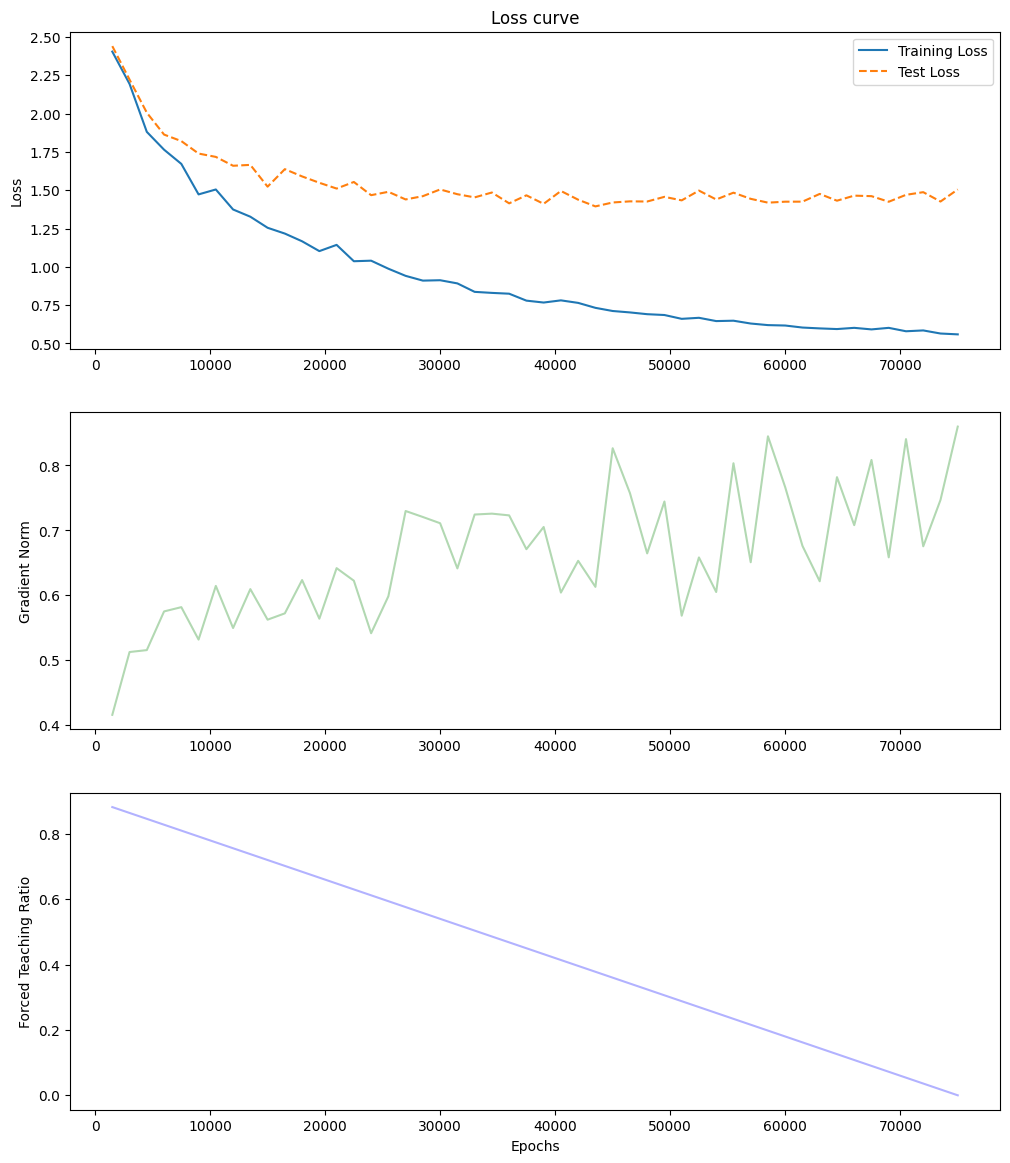

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Plot training and test loss on the first subplot
ax1.plot(epoch_count, train_loss_values, label='Training Loss')
ax1.plot(epoch_count, test_loss_values, label='Test Loss', linestyle='--')
ax3.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curve')
ax1.legend(loc='upper right')

# Plot gradient norm on the second subplot
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.3)
ax3.set_xlabel('Epochs')
ax2.set_ylabel('Gradient Norm')

# Plot forced teaching ratio decay on the third subplot
ax3.plot(epoch_count, ratio_values, 'b', alpha=0.3)
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Forced Teaching Ratio')

plt.show()

In [19]:
import re
from nltk import word_tokenize

def translate(sentence, max_output_length=20):
    tokens, _ = model.evaluate(sentence, max_output_length)

    tokens = [t for t in tokens if t not in (eos_token, sos_token)]
    new_sentence = ' '.join(tokens).capitalize()
    new_sentence = re.sub(r'\s+([.,!?])', r'\1', new_sentence)

    return new_sentence

In [20]:
### Use model ###

print(translate('Go!'))
print(translate('It\'s Fine.'))
print(translate('I\'m very happy.'))
print(translate('He\'s very sad.'))
print(translate('That man is wearing a white shirt.'))
print(translate('He\'s afraid of spiders.'))
print(translate('He\'s going home to his wife.'))
print(translate('Those guys are walking to work.'))
print(translate('I\'m not going with you today.'))
print(translate('My girlfriend will not come over tomorrow.'))
print(translate('He bought his friends a nice present for christmas.'))


Kam!! project project project project aan reis.
Het is gratis.
Gelukkig gelukkig gelukkig..
Hij verdrietig verdrietig canada verrassing verrassing vrees gebruik. ''
Die jurk ​​een witte shirt shirt.
Hij heeft spinnen. spinnen.
Hij gaat naar naar zijn school.
Aardbevingen werken werken.
Ik ga vandaag met je mee..
Mijn komt morgen morgen morgen langs langs. <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
Hij heeft een vrienden cadeau voor kerst voor kerst.


In [30]:
from nltk import word_tokenize
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def showAttention(input_sentence, output_tokens, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)
                       
    input_tokens = [sos_token] + word_tokenize(input_sentence.lower()) + [eos_token]

    # print('input:', input_tokens)
    # print('output:', output_tokens)

    # Set up axes
    ax.set_xticklabels(input_tokens, rotation=90)
    ax.set_yticklabels(output_tokens)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_tokens, attentions = model.evaluate(input_sentence)

    attentions = attentions.cpu()

    input_tokens = word_tokenize(input_sentence.lower()) + [eos_token]

    showAttention(input_sentence, output_tokens, attentions[:, 1:])

input: ['<sos>', 'that', 'man', 'is', 'wearing', 'a', 'white', 'shirt', 'and', 'looking', 'at', 'something', '.', '<eos>']
output: ['<sos>', 'die', 'man', 'draagt', 'een', 'witte', 'shirt', 'en', 'kijkt', 'naar', 'iets', '.', '<eos>']


/tmp/ipykernel_92854/2210169264.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(input_tokens, rotation=90)
/tmp/ipykernel_92854/2210169264.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(output_tokens)


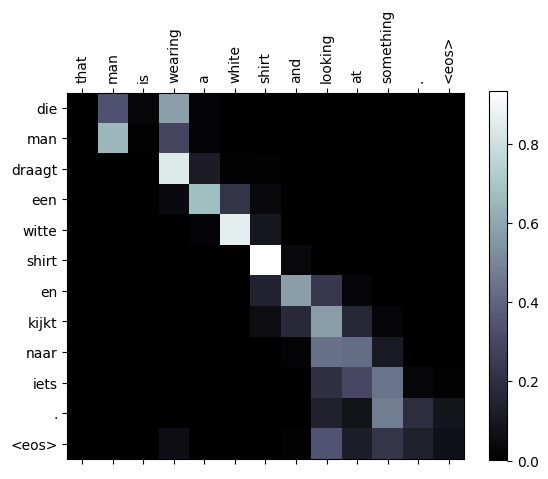

In [31]:
evaluateAndShowAttention('That man is wearing a white shirt and looking at something.')